In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import math
import os
import re
import urllib.request
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

### 1. 데이터 불러오기 및 길이 분포 확인



In [2]:


data_path = Path.home() / "data/songys_chatbot/ChatbotData.csv"

chatbot_df = pd.read_csv(data_path)

print("사용한 데이터 경로:", data_path)
print("데이터 크기:", chatbot_df.shape)
print("컬럼:", chatbot_df.columns.tolist())

display(chatbot_df.head())


사용한 데이터 경로: /home/thkim0/data/songys_chatbot/ChatbotData.csv
데이터 크기: (11823, 3)
컬럼: ['Q', 'A', 'label']


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [3]:
label_names = {
    0: "daily",
    1: "breakup_negative",
    2: "love_positive",
}

label_counts = (
    chatbot_df["label"]
    .value_counts()
    .sort_index()
    .rename_axis("label")
    .reset_index(name="count")
)
label_counts["label_name"] = label_counts["label"].map(label_names)
label_counts["ratio"] = label_counts["count"] / len(chatbot_df)

print("결측치 개수")
display(chatbot_df.isna().sum().to_frame("missing_count"))

print("레이블 분포")
display(label_counts[["label", "label_name", "count", "ratio"]])


결측치 개수


,missing_count
Q,0
A,0
label,0


레이블 분포


,label,label_name,count,ratio
0,0,daily,5290,0.447433
1,1,breakup_negative,3570,0.301954
2,2,love_positive,2963,0.250613


In [4]:
length_df = chatbot_df.copy()

# 문자 길이: 한글 문장 전체 길이를 보는 기준입니다.
length_df["q_char_len"] = length_df["Q"].astype(str).str.len()
length_df["a_char_len"] = length_df["A"].astype(str).str.len()

# 공백 기준 어절 길이: 아직 tokenizer를 학습하기 전의 대략적인 문장 길이 기준입니다.
length_df["q_word_len"] = length_df["Q"].astype(str).str.split().str.len()
length_df["a_word_len"] = length_df["A"].astype(str).str.split().str.len()

length_columns = ["q_char_len", "a_char_len", "q_word_len", "a_word_len"]
percentiles = [0.5, 0.75, 0.90, 0.95, 0.97, 0.99, 1.0]

length_summary = length_df[length_columns].describe(percentiles=percentiles).T
length_summary = length_summary[["mean", "std", "min", "50%", "75%", "90%", "95%", "97%", "99%", "max"]]

print("질문/답변 길이 요약")
display(length_summary)


질문/답변 길이 요약


,mean,std,min,50%,75%,90%,95%,97%,99%,max
q_char_len,12.879049,6.167467,1.0,12.0,16.0,21.0,25.0,27.0,32.0,56.0
a_char_len,15.015140,6.701835,1.0,14.0,18.0,23.0,27.0,31.0,37.0,76.0
q_word_len,3.587414,1.618897,1.0,3.0,4.0,6.0,7.0,7.0,8.0,15.0
a_word_len,3.693648,1.857292,1.0,3.0,5.0,6.0,7.0,8.0,10.0,21.0


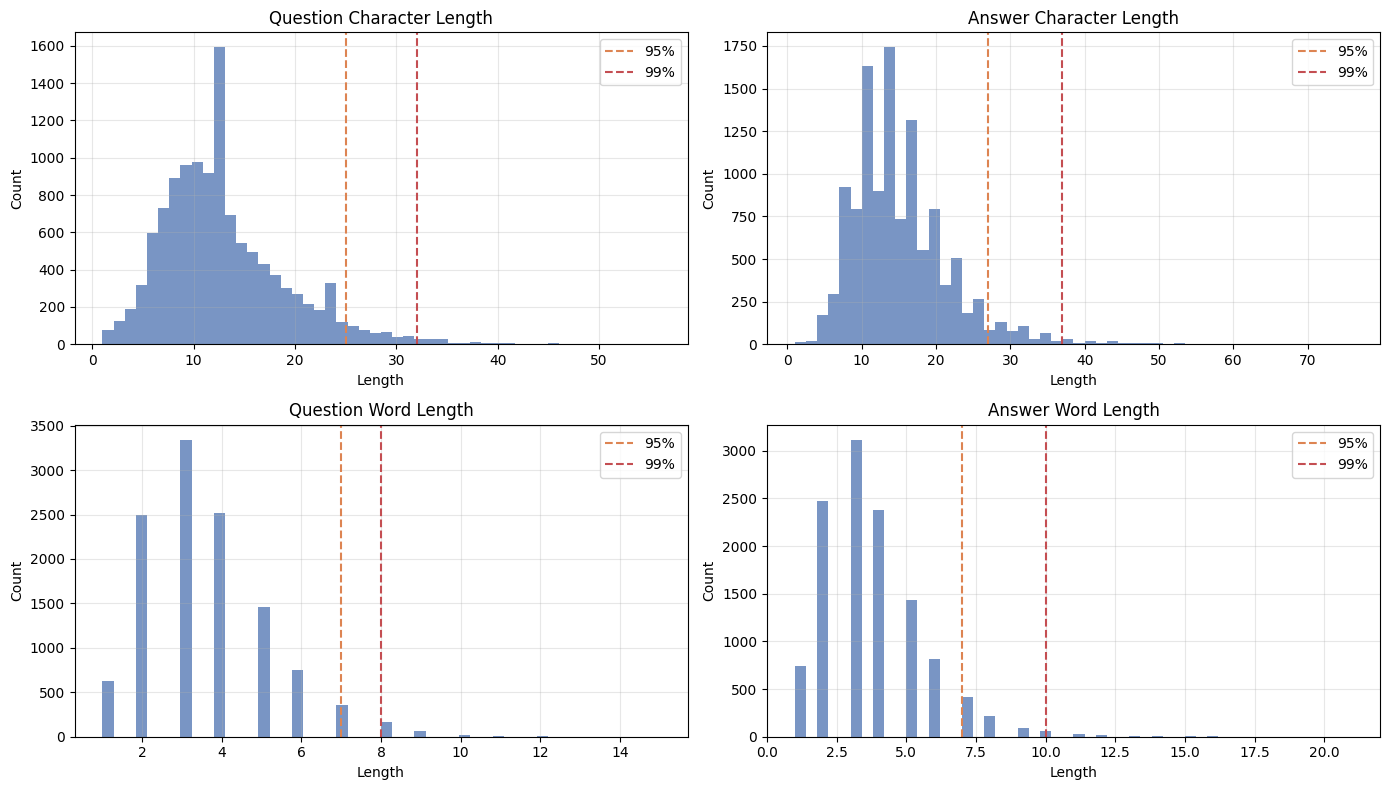

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_configs = [
    ("q_char_len", "Question Character Length", axes[0, 0]),
    ("a_char_len", "Answer Character Length", axes[0, 1]),
    ("q_word_len", "Question Word Length", axes[1, 0]),
    ("a_word_len", "Answer Word Length", axes[1, 1]),
]

for column, title, ax in plot_configs:
    ax.hist(length_df[column], bins=50, color="#4C72B0", alpha=0.75)
    ax.axvline(length_df[column].quantile(0.95), color="#DD8452", linestyle="--", label="95%")
    ax.axvline(length_df[column].quantile(0.99), color="#C44E52", linestyle="--", label="99%")
    ax.set_title(title)
    ax.set_xlabel("Length")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


원래 기존 문장의 99%를 포함할수 있는 40글자 제한을 적용해 자르려고 했으나, 데이터도 그렇게 많지도 않고 긴건 보통 답변측이라 자르면 문제가 발생할것 같아 자르지 않음
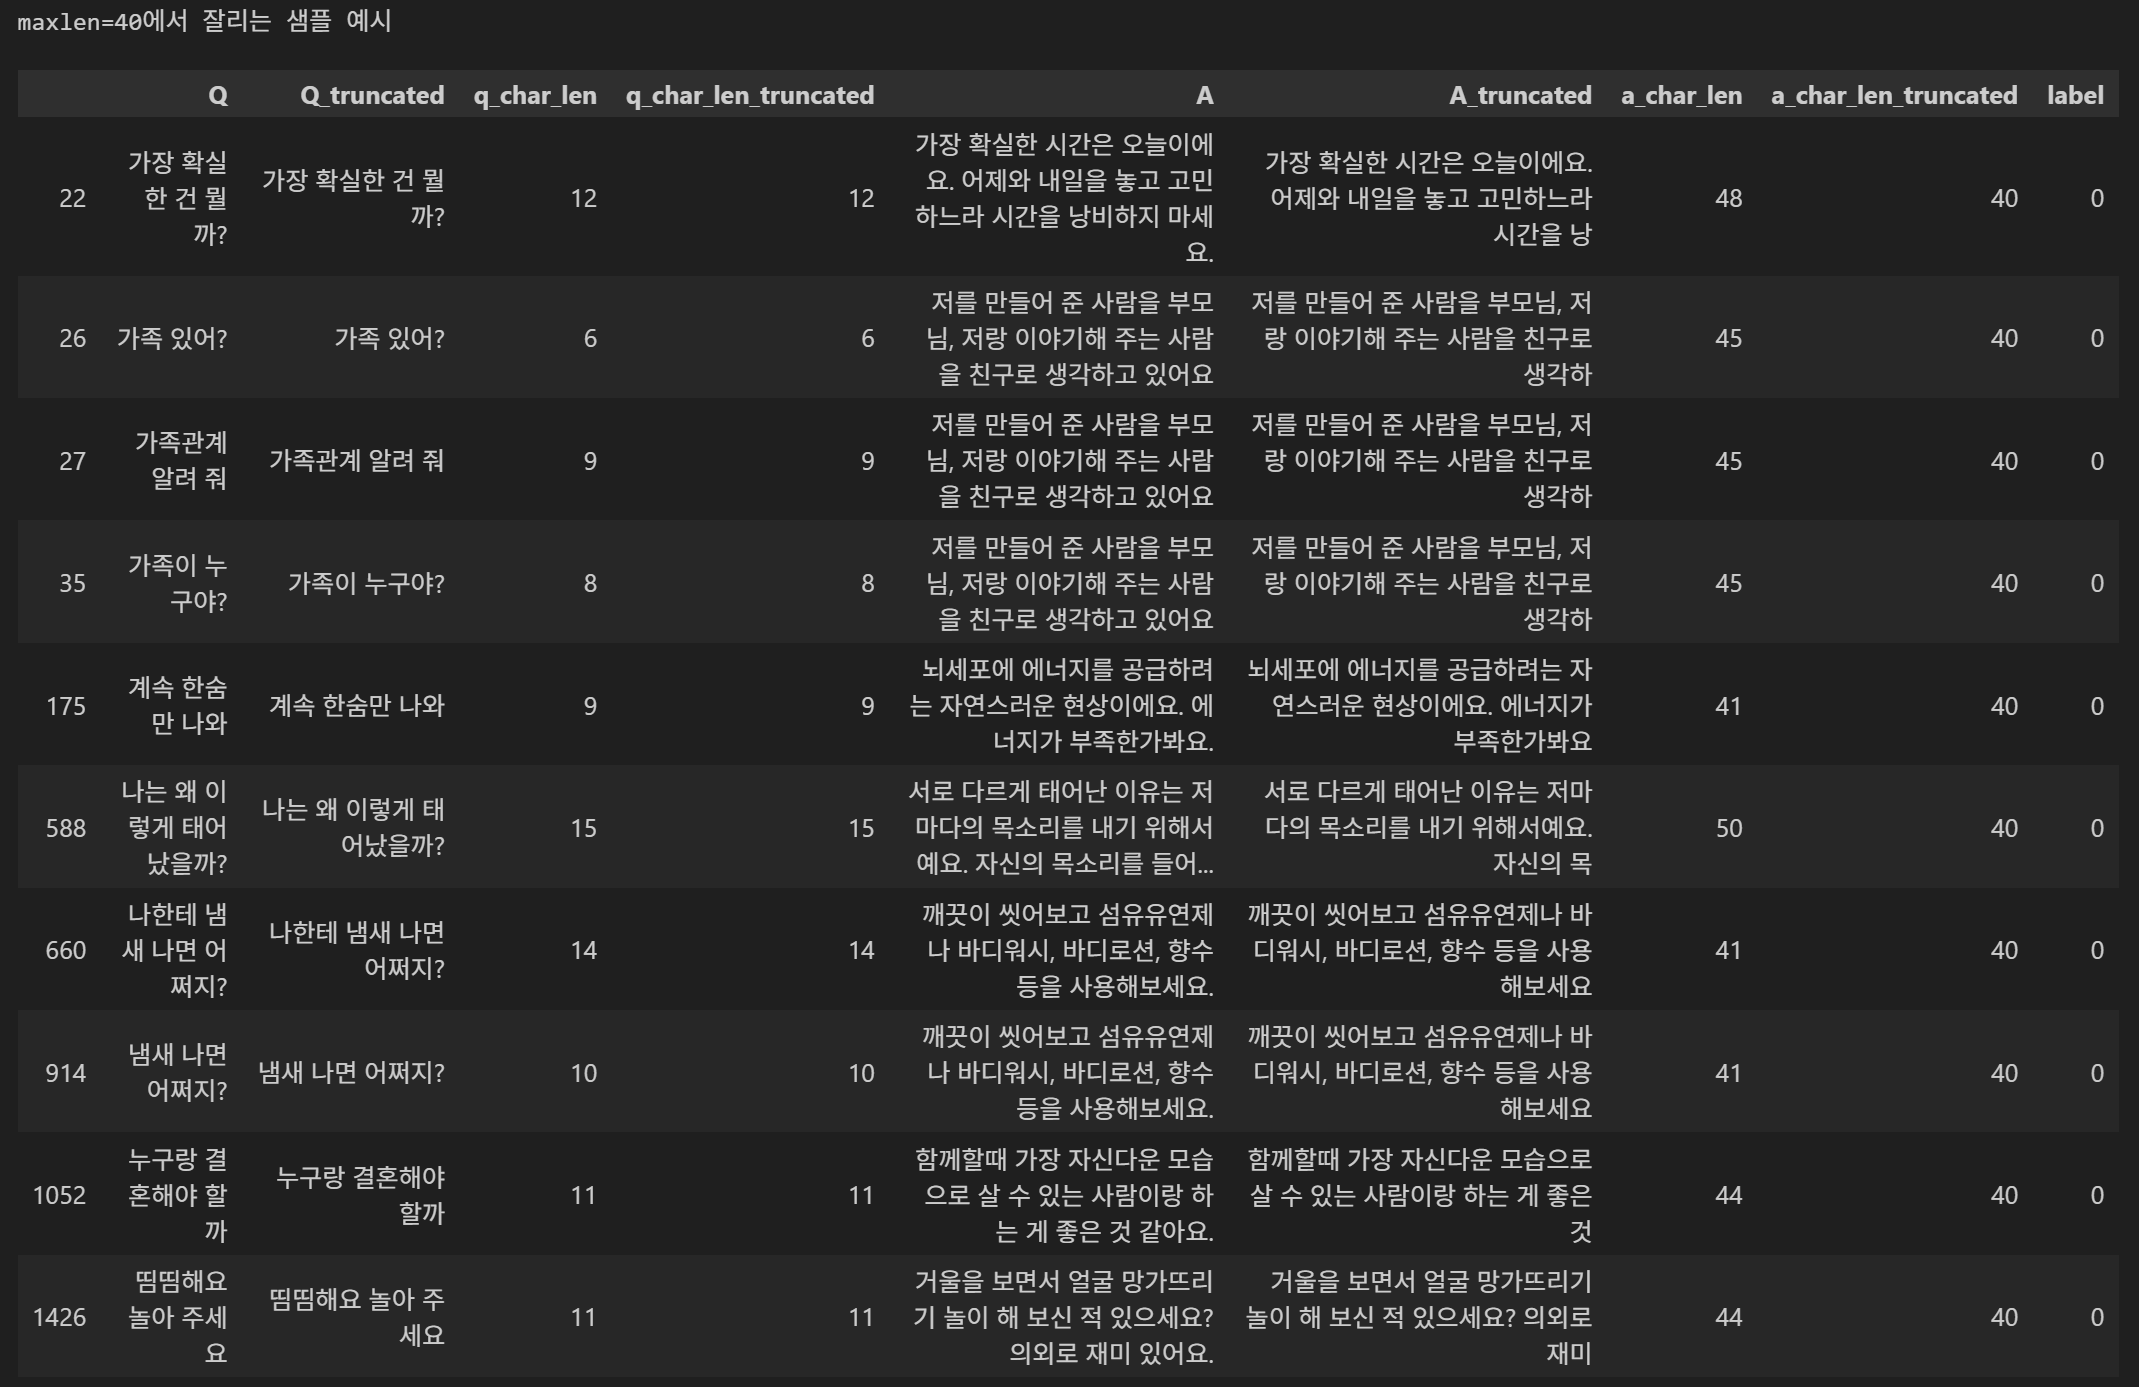

### 2. 전체 문장 사용 기준 확인

`maxlen=40`으로 문자 단위 truncation을 적용하지 않고, 원본 질문(`Q`)과 답변(`A`) 전체를 그대로 사용합니다.  
이 셀에서는 전체 데이터를 사용할 때의 최대 길이와, 만약 40자를 기준으로 삼았을 때 영향을 받았을 샘플 수만 참고용으로 확인합니다.


In [6]:
REFERENCE_MAXLEN = 40

full_length_check = pd.DataFrame({
    "column": ["Q", "A"],
    "use_text": ["original", "original"],
    "max_char_len": [length_df["q_char_len"].max(), length_df["a_char_len"].max()],
    "p95_char_len": [
        int(np.ceil(length_df["q_char_len"].quantile(0.95))),
        int(np.ceil(length_df["a_char_len"].quantile(0.95))),
    ],
    "p99_char_len": [
        int(np.ceil(length_df["q_char_len"].quantile(0.99))),
        int(np.ceil(length_df["a_char_len"].quantile(0.99))),
    ],
    "over_40_count_reference": [
        int((length_df["q_char_len"] > REFERENCE_MAXLEN).sum()),
        int((length_df["a_char_len"] > REFERENCE_MAXLEN).sum()),
    ],
})
full_length_check["over_40_ratio_reference"] = (
    full_length_check["over_40_count_reference"] / len(length_df)
)

print("문자 단위 truncation 없이 전체 문장을 사용합니다.")
display(full_length_check)


문자 단위 truncation 없이 전체 문장을 사용합니다.


,column,use_text,max_char_len,p95_char_len,p99_char_len,over_40_count_reference,over_40_ratio_reference
0,Q,original,56,25,32,18,0.001522
1,A,original,76,27,37,89,0.007528


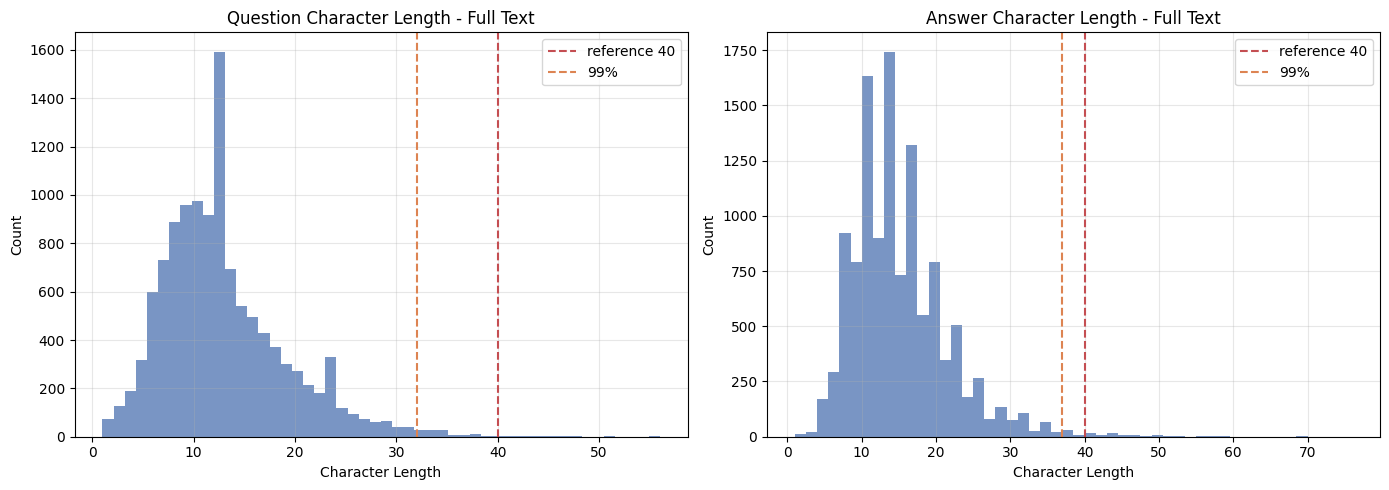

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_configs = [
    ("q_char_len", "Question Character Length - Full Text", axes[0]),
    ("a_char_len", "Answer Character Length - Full Text", axes[1]),
]

for column, title, ax in plot_configs:
    ax.hist(length_df[column], bins=50, color="#4C72B0", alpha=0.75)
    ax.axvline(REFERENCE_MAXLEN, color="#C44E52", linestyle="--", label="reference 40")
    ax.axvline(length_df[column].quantile(0.99), color="#DD8452", linestyle="--", label="99%")
    ax.set_title(title)
    ax.set_xlabel("Character Length")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


### 3. 한국어 전처리

이 데이터셋은 이미 비교적 짧은 한국어 문장으로 구성되어 있지만, 토크나이저 학습 전에 문자열 형태를 통일합니다.  
`label`은 챗봇 답변 생성 모델의 입력으로 넣지 않고, train/validation split의 비율 유지와 label별 생성 결과 분석에만 사용합니다.


In [8]:
import unicodedata
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pad_sequence

label_names = {
    0: "daily",
    1: "breakup_negative",
    2: "love_positive",
}


def preprocess_sentence(sentence):
    sentence = unicodedata.normalize("NFC", str(sentence))
    sentence = re.sub(r"([?.!,])", r"  ", sentence)
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence


df_clean = chatbot_df.copy()
df_clean["Q_clean"] = df_clean["Q"].map(preprocess_sentence)
df_clean["A_clean"] = df_clean["A"].map(preprocess_sentence)

before_count = len(df_clean)
df_clean = df_clean[(df_clean["Q_clean"] != "") & (df_clean["A_clean"] != "")].copy()
df_clean = df_clean.reset_index(drop=True)
after_count = len(df_clean)

print(f"전처리 전 샘플 수: {before_count}")
print(f"전처리 후 샘플 수: {after_count}")
print(f"제거된 샘플 수: {before_count - after_count}")

comparison_cols = ["Q", "Q_clean", "A", "A_clean", "label"]
display(df_clean[comparison_cols].head(10))

clean_label_counts = (
    df_clean["label"]
    .value_counts(normalize=True)
    .sort_index()
    .rename_axis("label")
    .reset_index(name="ratio")
)
clean_label_counts["label_name"] = clean_label_counts["label"].map(label_names)
clean_label_counts["count"] = df_clean["label"].value_counts().sort_index().values

print("전처리 후 label 분포")
display(clean_label_counts[["label", "label_name", "count", "ratio"]])


전처리 전 샘플 수: 11823
전처리 후 샘플 수: 11823
제거된 샘플 수: 0


,Q,Q_clean,A,A_clean,label
0,12시 땡!,12시 땡,하루가 또 가네요.,하루가 또 가네요,0
1,1지망 학교 떨어졌어,1지망 학교 떨어졌어,위로해 드립니다.,위로해 드립니다,0
2,3박4일 놀러가고 싶다,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,여행은 언제나 좋죠,0
3,3박4일 정도 놀러가고 싶다,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,여행은 언제나 좋죠,0
4,PPL 심하네,PPL 심하네,눈살이 찌푸려지죠.,눈살이 찌푸려지죠,0
5,SD카드 망가졌어,SD카드 망가졌어,다시 새로 사는 게 마음 편해요.,다시 새로 사는 게 마음 편해요,0
6,SD카드 안돼,SD카드 안돼,다시 새로 사는 게 마음 편해요.,다시 새로 사는 게 마음 편해요,0
7,SNS 맞팔 왜 안하지ㅠㅠ,SNS 맞팔 왜 안하지,잘 모르고 있을 수도 있어요.,잘 모르고 있을 수도 있어요,0
8,SNS 시간낭비인 거 아는데 매일 하는 중,SNS 시간낭비인 거 아는데 매일 하는 중,시간을 정하고 해보세요.,시간을 정하고 해보세요,0
9,SNS 시간낭비인데 자꾸 보게됨,SNS 시간낭비인데 자꾸 보게됨,시간을 정하고 해보세요.,시간을 정하고 해보세요,0


전처리 후 label 분포


,label,label_name,count,ratio
0,0,daily,5290,0.447433
1,1,breakup_negative,3570,0.301954
2,2,love_positive,2963,0.250613


### 4. Stratified Train/Validation Split

세 label의 비율이 서로 다르므로 단순 random split 대신 `label`을 기준으로 stratified split을 적용합니다.  
여기서 validation set은 최종 test set이 아니라 학습 중 loss 확인, best checkpoint 선택, early stopping을 위한 내부 검증 데이터입니다.


In [9]:
train_df, val_df = train_test_split(
    df_clean,
    test_size=0.1,
    random_state=42,
    stratify=df_clean["label"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)


def label_ratio_table(df, split_name):
    table = (
        df["label"]
        .value_counts(normalize=True)
        .sort_index()
        .rename_axis("label")
        .reset_index(name="ratio")
    )
    table["label_name"] = table["label"].map(label_names)
    table["count"] = df["label"].value_counts().sort_index().values
    table["split"] = split_name
    return table[["split", "label", "label_name", "count", "ratio"]]

split_ratio = pd.concat([
    label_ratio_table(df_clean, "all"),
    label_ratio_table(train_df, "train"),
    label_ratio_table(val_df, "validation"),
], ignore_index=True)

print(f"전체 데이터 수: {len(df_clean)}")
print(f"train 데이터 수: {len(train_df)}")
print(f"validation 데이터 수: {len(val_df)}")
display(split_ratio)


전체 데이터 수: 11823
train 데이터 수: 10640
validation 데이터 수: 1183


,split,label,label_name,count,ratio
0,all,0,daily,5290,0.447433
1,all,1,breakup_negative,3570,0.301954
2,all,2,love_positive,2963,0.250613
3,train,0,daily,4761,0.447462
4,train,1,breakup_negative,3213,0.301974
5,train,2,love_positive,2666,0.250564
6,validation,0,daily,529,0.447168
7,validation,1,breakup_negative,357,0.301775
8,validation,2,love_positive,297,0.251057


### 5. SentencePiece 토크나이저

형태소 분석기 대신 SentencePiece를 사용합니다. SentencePiece는 공백 기준 단어뿐 아니라 subword 단위로 문장을 나누므로, 처음 보는 표현이나 짧은 한국어 문장에도 비교적 유연하게 대응할 수 있습니다.  
토크나이저는 validation 정보를 섞지 않기 위해 train set의 전처리된 질문과 답변만 사용해 학습합니다.

`decode_ids()`에서는 `<s>`, `</s>` 같은 control token이 출력 문자열에 보이지 않을 수 있습니다. 이 토큰들은 문자열 복원용 글자가 아니라 모델 입력/출력의 시작과 끝을 알려주는 내부 id이기 때문입니다.


In [ ]:
VOCAB_SIZE = 4000

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "quest.ipynb").exists() and (PROJECT_DIR / "Exploration/Ex08").exists():
    PROJECT_DIR = PROJECT_DIR / "Exploration/Ex08"

spm_model_prefix = PROJECT_DIR / "spm_korean_chatbot_unigram"
spm_model_path = spm_model_prefix.with_suffix(".model")
spm_vocab_path = spm_model_prefix.with_suffix(".vocab")
spm_corpus_path = PROJECT_DIR / "spm_korean_chatbot_train_corpus.txt"

if not spm_model_path.exists():
    with open(spm_corpus_path, "w", encoding="utf-8") as f:
        for question, answer in train_df[["Q_clean", "A_clean"]].itertuples(index=False):
            f.write(question + "\n")
            f.write(answer + "\n")

    spm.SentencePieceTrainer.Train(
        input=str(spm_corpus_path),
        model_prefix=str(spm_model_prefix),
        vocab_size=VOCAB_SIZE,
        character_coverage=1.0,
        model_type="unigram",
        pad_id=0,
        bos_id=1,
        eos_id=2,
        unk_id=3,
        pad_piece="<pad>",
        bos_piece="<s>",
        eos_piece="</s>",
        unk_piece="<unk>",
        hard_vocab_limit=False,
    )
    print("SentencePiece 모델 학습 완료:", spm_model_path)
else:
    print("기존 SentencePiece 모델 로드:", spm_model_path)

sp = spm.SentencePieceProcessor()
sp.Load(str(spm_model_path))

PAD_ID = sp.pad_id()
BOS_ID = sp.bos_id()
EOS_ID = sp.eos_id()
UNK_ID = sp.unk_id()

print("PAD_ID, BOS_ID, EOS_ID, UNK_ID:", PAD_ID, BOS_ID, EOS_ID, UNK_ID)
print("PAD piece:", sp.id_to_piece(PAD_ID))
print("BOS piece:", sp.id_to_piece(BOS_ID))
print("EOS piece:", sp.id_to_piece(EOS_ID))
print("UNK piece:", sp.id_to_piece(UNK_ID))
print("vocab size:", sp.GetPieceSize())


### 6. SentencePiece Token Length 분석

문자 길이 기준으로는 문장을 자르지 않기로 했고, SentencePiece token 시퀀스도 임의로 자르지 않습니다.  
아래 길이 분석은 positional encoding 길이와 inference generation limit을 정하기 위한 확인용입니다.


In [11]:
def encode_question(text):
    return sp.encode_as_ids(text)


def encode_answer_full(text):
    return [BOS_ID] + sp.encode_as_ids(text) + [EOS_ID]


for frame in (train_df, val_df):
    frame["q_token_len"] = frame["Q_clean"].map(lambda text: len(encode_question(text)))
    frame["a_token_len"] = frame["A_clean"].map(lambda text: len(sp.encode_as_ids(text)))
    frame["a_token_len_with_bos_eos"] = frame["A_clean"].map(lambda text: len(encode_answer_full(text)))

length_token_cols = ["q_token_len", "a_token_len", "a_token_len_with_bos_eos"]
token_length_summary = pd.concat([
    train_df[length_token_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.97, 0.99]).T.assign(split="train"),
    val_df[length_token_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.97, 0.99]).T.assign(split="validation"),
])

display(token_length_summary[["split", "mean", "std", "min", "50%", "75%", "90%", "95%", "97%", "99%", "max"]])

max_question_token_len = int(max(train_df["q_token_len"].max(), val_df["q_token_len"].max()))
max_answer_full_len = int(max(train_df["a_token_len_with_bos_eos"].max(), val_df["a_token_len_with_bos_eos"].max()))

MAX_ENCODER_POSITION = max(max_question_token_len + 1, 128)
MAX_GENERATION_LENGTH = max_answer_full_len
MAX_DECODER_POSITION = max(MAX_GENERATION_LENGTH + 1, 128)

print("max_question_token_len:", max_question_token_len)
print("max_answer_full_len:", max_answer_full_len)
print("MAX_ENCODER_POSITION:", MAX_ENCODER_POSITION)
print("MAX_DECODER_POSITION:", MAX_DECODER_POSITION)
print("MAX_GENERATION_LENGTH:", MAX_GENERATION_LENGTH)


,split,mean,std,min,50%,75%,90%,95%,97%,99%,max
q_token_len,train,6.114098,2.763401,1.0,6.0,8.0,10.0,11.0,12.0,15.00,25.0
a_token_len,train,6.405733,3.131445,1.0,6.0,8.0,10.0,12.0,13.0,17.00,35.0
a_token_len_with_bos_eos,train,8.405733,3.131445,3.0,8.0,10.0,12.0,14.0,15.0,19.00,37.0
q_token_len,validation,6.393914,3.011882,1.0,6.0,8.0,10.0,12.0,13.0,15.18,26.0
a_token_len,validation,6.539307,3.237095,1.0,6.0,8.0,11.0,12.0,13.0,17.00,22.0
a_token_len_with_bos_eos,validation,8.539307,3.237095,3.0,8.0,10.0,13.0,14.0,15.0,19.00,24.0


max_question_token_len: 26
max_answer_full_len: 37
MAX_ENCODER_POSITION: 128
MAX_DECODER_POSITION: 128
MAX_GENERATION_LENGTH: 37


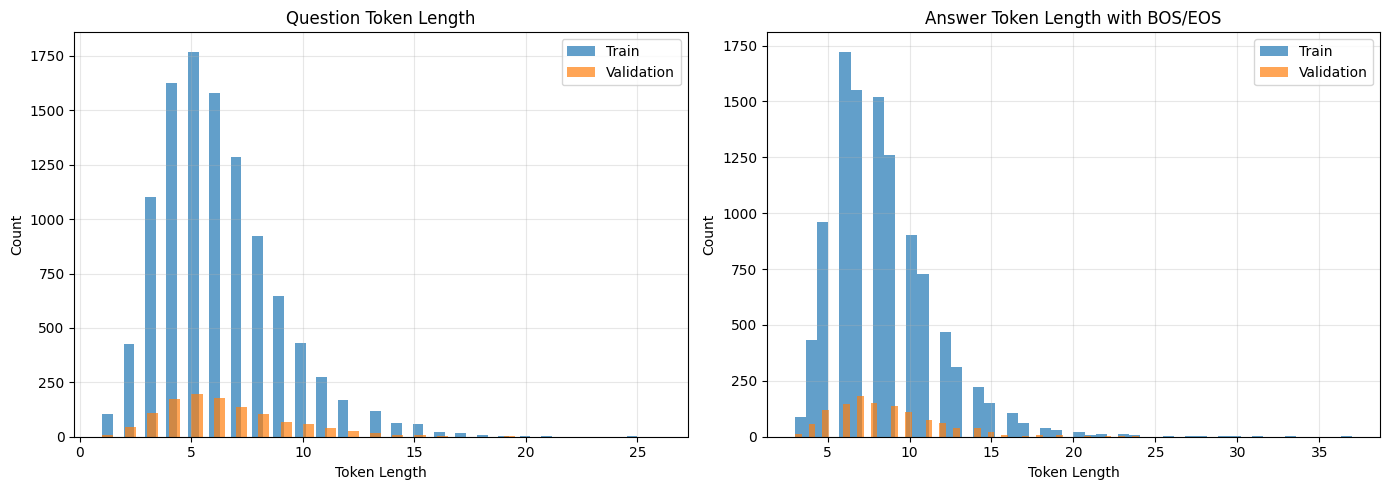

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df["q_token_len"], bins=50, alpha=0.7, label="Train")
axes[0].hist(val_df["q_token_len"], bins=50, alpha=0.7, label="Validation")
axes[0].set_title("Question Token Length")
axes[0].set_xlabel("Token Length")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(train_df["a_token_len_with_bos_eos"], bins=50, alpha=0.7, label="Train")
axes[1].hist(val_df["a_token_len_with_bos_eos"], bins=50, alpha=0.7, label="Validation")
axes[1].set_title("Answer Token Length with BOS/EOS")
axes[1].set_xlabel("Token Length")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


### 7. Dataset과 동적 Padding DataLoader

질문은 encoder input으로 사용하고, 답변은 teacher forcing을 위해 한 칸 shift합니다.  
예를 들어 답변 전체가 `[<s>, t1, t2, </s>]`라면 decoder input은 `[<s>, t1, t2]`, decoder label은 `[t1, t2, </s>]`가 됩니다.  
문장 길이는 자르지 않고 batch 내부에서만 `pad_sequence`로 padding합니다.


In [13]:
class KoreanChatbotDataset(Dataset):
    def __init__(self, dataframe, sp_processor):
        self.questions = dataframe["Q_clean"].tolist()
        self.answers = dataframe["A_clean"].tolist()
        self.sp = sp_processor

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        encoder_input = self.sp.encode_as_ids(self.questions[idx])
        answer_ids = [BOS_ID] + self.sp.encode_as_ids(self.answers[idx]) + [EOS_ID]

        decoder_input = answer_ids[:-1]
        decoder_label = answer_ids[1:]

        return (
            torch.tensor(encoder_input, dtype=torch.long),
            torch.tensor(decoder_input, dtype=torch.long),
            torch.tensor(decoder_label, dtype=torch.long),
        )


def chatbot_collate_fn(batch):
    encoder_inputs, decoder_inputs, decoder_labels = zip(*batch)

    encoder_inputs = pad_sequence(encoder_inputs, batch_first=True, padding_value=PAD_ID)
    decoder_inputs = pad_sequence(decoder_inputs, batch_first=True, padding_value=PAD_ID)
    decoder_labels = pad_sequence(decoder_labels, batch_first=True, padding_value=PAD_ID)

    return encoder_inputs, decoder_inputs, decoder_labels


BATCH_SIZE = 32
pin_memory = torch.cuda.is_available()

train_dataset = KoreanChatbotDataset(train_df, sp)
val_dataset = KoreanChatbotDataset(val_df, sp)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=chatbot_collate_fn,
    num_workers=0,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=chatbot_collate_fn,
    num_workers=0,
    pin_memory=pin_memory,
)

for encoder_input, decoder_input, decoder_label in train_loader:
    print("encoder_input.shape:", encoder_input.shape)
    print("decoder_input.shape:", decoder_input.shape)
    print("decoder_label.shape:", decoder_label.shape)
    break


encoder_input.shape: torch.Size([32, 11])
decoder_input.shape: torch.Size([32, 12])
decoder_label.shape: torch.Size([32, 12])


### 8. Transformer 모델

Transformer는 encoder가 질문을 문맥 표현으로 바꾸고, decoder가 이전 답변 token을 보면서 다음 token을 예측하는 구조입니다.  
`padding mask`는 `<pad>` 위치를 attention에서 제외하고, `look-ahead mask`는 decoder가 미래 정답 token을 미리 보지 못하게 합니다.  
positional encoding 길이는 vocab size가 아니라 실제 token sequence 길이 기준으로 잡습니다. vocab size는 token 종류의 개수이고, position은 문장 안에서 token이 놓인 위치이기 때문입니다.


In [14]:
def create_padding_mask(x, pad_id=PAD_ID):
    mask = (x == pad_id).float()
    return mask.unsqueeze(1).unsqueeze(2)


def create_look_ahead_mask(x, pad_id=PAD_ID):
    seq_len = x.size(1)
    look_ahead_mask = torch.triu(
        torch.ones((seq_len, seq_len), device=x.device),
        diagonal=1,
    )
    look_ahead_mask = look_ahead_mask.unsqueeze(0).unsqueeze(1)
    padding_mask = create_padding_mask(x, pad_id=pad_id)
    return torch.maximum(look_ahead_mask, padding_mask)


class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super().__init__()
        self.position = position
        self.d_model = d_model
        self.register_buffer("pos_encoding", self._build_pos_encoding(position, d_model))

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)
        angle_rads = pos / torch.pow(10000, (2 * (i // 2)) / d_model)

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])
        return pos_encoding.unsqueeze(0)

    def forward(self, x):
        seq_len = x.size(1)
        if seq_len > self.position:
            raise ValueError(
                f"sequence length {seq_len} exceeds positional encoding length {self.position}"
            )
        return x + self.pos_encoding[:, :seq_len, :]


def scaled_dot_product_attention(query, key, value, mask=None):
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))
    depth = key.size(-1)
    logits = matmul_qk / math.sqrt(depth)

    if mask is not None:
        logits = logits + (mask * -1e9)

    attention_weights = F.softmax(logits, dim=-1)
    output = torch.matmul(attention_weights, value)
    return output, attention_weights


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0

        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)
        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        query = self.split_heads(self.query_dense(query), batch_size)
        key = self.split_heads(self.key_dense(key), batch_size)
        value = self.split_heads(self.value_dense(value), batch_size)

        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)
        return self.out_dense(concat_attention)


In [15]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model),
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        attn_output = self.mha(x, x, x, mask)
        attn_output = self.dropout1(attn_output)
        out1 = self.norm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        return self.norm2(out1 + ffn_output)


class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model),
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)

        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)

        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        return self.norm3(out2 + ffn_out)


In [16]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, num_layers, ff_dim, d_model, num_heads, max_position, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_encoding = PositionalEncoding(position=max_position, d_model=d_model)
        self.dropout = nn.Dropout(dropout)
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        for layer in self.enc_layers:
            x = layer(x, mask)
        return x


class Decoder(nn.Module):
    def __init__(self, vocab_size, num_layers, ff_dim, d_model, num_heads, max_position, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_encoding = PositionalEncoding(position=max_position, d_model=d_model)
        self.dropout = nn.Dropout(dropout)
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)
        return x


class Transformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_layers,
        units,
        d_model,
        num_heads,
        max_encoder_position,
        max_decoder_position,
        dropout=0.1,
        pad_id=PAD_ID,
    ):
        super().__init__()
        self.pad_id = pad_id
        self.max_encoder_position = max_encoder_position
        self.max_decoder_position = max_decoder_position

        self.encoder = Encoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            max_position=max_encoder_position,
            dropout=dropout,
        )
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            max_position=max_decoder_position,
            dropout=dropout,
        )
        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, inputs, dec_inputs):
        enc_padding_mask = create_padding_mask(inputs, pad_id=self.pad_id)
        look_ahead_mask = create_look_ahead_mask(dec_inputs, pad_id=self.pad_id)
        dec_padding_mask = create_padding_mask(inputs, pad_id=self.pad_id)

        enc_outputs = self.encoder(inputs, mask=enc_padding_mask)
        dec_outputs = self.decoder(
            dec_inputs,
            enc_outputs=enc_outputs,
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask,
        )
        return self.final_linear(dec_outputs)


In [17]:
NUM_LAYERS = 2
D_MODEL = 256
NUM_HEADS = 4
UNITS = 512
DROPOUT = 0.1
VOCAB_SIZE = sp.GetPieceSize()
EPOCHS = 30
WARMUP_STEPS = 1000
PATIENCE = 5
MIN_DELTA = 1e-4


def get_lr_lambda(d_model, warmup_steps=1000):
    d_model = float(d_model)

    def lr_lambda(step):
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))

    return lr_lambda


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    max_encoder_position=MAX_ENCODER_POSITION,
    max_decoder_position=MAX_DECODER_POSITION,
    dropout=DROPOUT,
    pad_id=PAD_ID,
).to(device)

loss_function = nn.CrossEntropyLoss(ignore_index=PAD_ID)
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=WARMUP_STEPS),
)

print("device:", device)
print("model parameters:", sum(p.numel() for p in model.parameters()))
print("VOCAB_SIZE:", VOCAB_SIZE)


device: cuda
model parameters: 5711776
VOCAB_SIZE: 4000


### 9. 학습 루프, History, Early Stopping

loss와 accuracy 계산은 `Ex08/node.ipynb`의 학습 노드 흐름을 최대한 유지합니다.  
`CrossEntropyLoss(ignore_index=PAD_ID)`로 padding token은 loss에서 제외하고, accuracy도 padding 위치를 제외한 token 기준으로 계산합니다.  
validation loss가 개선될 때 best checkpoint를 저장하고, 일정 epoch 동안 개선이 없으면 early stopping을 적용합니다.


In [18]:
def accuracy_function(y_pred, y_true, pad_id=PAD_ID):
    preds = y_pred.argmax(dim=-1)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    total = mask.float().sum()

    if total.item() == 0:
        return torch.tensor(0.0, device=y_pred.device)

    return correct.float().sum() / total


def train_step(model, batch, optimizer, loss_function, scheduler, device):
    model.train()
    enc_input, dec_input, target = [x.to(device) for x in batch]

    optimizer.zero_grad()
    logits = model(enc_input, dec_input)
    loss = loss_function(logits.permute(0, 2, 1), target)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    acc = accuracy_function(logits, target, pad_id=PAD_ID)
    return loss.item(), acc.item()


def evaluate(model, data_loader, loss_function, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0

    with torch.no_grad():
        for batch in data_loader:
            enc_input, dec_input, target = [x.to(device) for x in batch]
            logits = model(enc_input, dec_input)
            loss = loss_function(logits.permute(0, 2, 1), target)
            acc = accuracy_function(logits, target, pad_id=PAD_ID)

            total_loss += loss.item()
            total_acc += acc.item()

    return total_loss / len(data_loader), total_acc / len(data_loader)


In [19]:
HISTORY_DIR = PROJECT_DIR / "histories"
HISTORY_PATH = HISTORY_DIR / "history_transformer_korean_chatbot_unigram.csv"
CHECKPOINT_PATH = HISTORY_DIR / "transformer_korean_chatbot_unigram_best.pt"


def checkpoint_config():
    return {
        "num_layers": NUM_LAYERS,
        "d_model": D_MODEL,
        "num_heads": NUM_HEADS,
        "units": UNITS,
        "dropout": DROPOUT,
        "vocab_size": VOCAB_SIZE,
        "max_encoder_position": MAX_ENCODER_POSITION,
        "max_decoder_position": MAX_DECODER_POSITION,
        "max_generation_length": MAX_GENERATION_LENGTH,
        "warmup_steps": WARMUP_STEPS,
        "pad_id": PAD_ID,
        "bos_id": BOS_ID,
        "eos_id": EOS_ID,
        "unk_id": UNK_ID,
    }


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    loss_function,
    scheduler,
    epochs,
    patience,
    min_delta,
    device,
):
    HISTORY_DIR.mkdir(parents=True, exist_ok=True)

    history = []
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss_sum = 0.0
        train_acc_sum = 0.0

        for step, batch in enumerate(train_loader, start=1):
            loss, acc = train_step(model, batch, optimizer, loss_function, scheduler, device)
            train_loss_sum += loss
            train_acc_sum += acc

            if step % 100 == 0:
                print(
                    f"  Step {step:04d} | "
                    f"Loss: {loss:.4f} | "
                    f"Acc: {acc:.4f} | "
                    f"LR: {scheduler.get_last_lr()[0]:.8f}"
                )

        train_loss = train_loss_sum / len(train_loader)
        train_acc = train_acc_sum / len(train_loader)
        val_loss, val_acc = evaluate(model, val_loader, loss_function, device)

        is_best = val_loss < best_val_loss - min_delta
        if is_best:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "best_val_loss": best_val_loss,
                    "config": checkpoint_config(),
                },
                CHECKPOINT_PATH,
            )
        else:
            patience_counter += 1

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "learning_rate": scheduler.get_last_lr()[0],
            "best_val_loss": best_val_loss,
            "patience_counter": patience_counter,
            "is_best": is_best,
        }
        history.append(row)
        history_df = pd.DataFrame(history)
        history_df.to_csv(HISTORY_PATH, index=False)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {scheduler.get_last_lr()[0]:.8f}"
        )

        if is_best:
            print(f"  -> Best checkpoint saved: {CHECKPOINT_PATH}")
        else:
            print(f"  -> EarlyStopping counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

    if CHECKPOINT_PATH.exists():
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        model.to(device)
        print("Best checkpoint loaded:", CHECKPOINT_PATH)

    print("History saved:", HISTORY_PATH)
    return pd.DataFrame(history)


def plot_loss_history(history_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training and Validation Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
    axes[1].plot(history_df["epoch"], history_df["val_acc"], label="Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Training and Validation Accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [ ]:
%%time

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    epochs=EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    device=device,
)

display(history)
plot_loss_history(history)


### 10. 예측 함수와 생성 결과 확인

예측 단계에서는 학습 때와 동일한 전처리와 SentencePiece 인코딩을 적용합니다.  
decoder는 `<s>` token에서 시작하고, 한 token씩 다음 token을 예측합니다. `</s>`가 나오거나 `MAX_GENERATION_LENGTH`에 도달하면 생성을 멈춥니다.


In [21]:
def load_best_checkpoint_if_exists(model, checkpoint_path=CHECKPOINT_PATH, device=device):
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        model.to(device)
        model.eval()
        print("Best checkpoint loaded:", checkpoint_path)
    else:
        print("Best checkpoint가 아직 없습니다. 먼저 학습 셀을 실행하세요.")
    return model


def predict(sentence, model=model, sp=sp, max_generation_length=MAX_GENERATION_LENGTH):
    model.eval()

    sentence = preprocess_sentence(sentence)
    encoder_ids = sp.encode_as_ids(sentence)
    if len(encoder_ids) == 0:
        return ""

    if len(encoder_ids) > model.max_encoder_position:
        raise ValueError(
            f"입력 token 길이({len(encoder_ids)})가 encoder position 길이({model.max_encoder_position})보다 깁니다. "
            "학습 데이터는 자르지 않았으며, 긴 자유 입력은 position 길이를 늘린 모델 설정이 필요합니다."
        )

    enc_input = torch.tensor([encoder_ids], dtype=torch.long, device=device)
    dec_input = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    generated_ids = []

    with torch.no_grad():
        for _ in range(max_generation_length):
            if dec_input.size(1) > model.max_decoder_position:
                break

            logits = model(enc_input, dec_input)
            next_id = int(torch.argmax(logits[:, -1, :], dim=-1).item())

            if next_id == EOS_ID:
                break
            if next_id in {PAD_ID, BOS_ID}:
                break

            generated_ids.append(next_id)
            next_tensor = torch.tensor([[next_id]], dtype=torch.long, device=device)
            dec_input = torch.cat([dec_input, next_tensor], dim=1)

    return sp.decode_ids(generated_ids)


In [22]:
test_sentences = [
    "오늘 너무 피곤해",
    "헤어진 지 열흘 됐어",
    "좋아하는 사람이 생겼어",
    "나 요즘 너무 외로워",
]

for sentence in test_sentences:
    print("Q:", sentence)
    print("A:", predict(sentence))
    print("-" * 40)


Q: 오늘 너무 피곤해
A: 인복이 많나봐요
----------------------------------------
Q: 헤어진 지 열흘 됐어
A: 애매하네요
----------------------------------------
Q: 좋아하는 사람이 생겼어
A: 그렇게 될 수 있지요
----------------------------------------
Q: 나 요즘 너무 외로워
A: 당신이 잘돼야 성덕이 될수있겠죠
----------------------------------------


In [23]:
def show_validation_predictions(samples_per_label=2, random_state=42):
    for label_value, label_name in label_names.items():
        samples = val_df[val_df["label"] == label_value].sample(
            n=min(samples_per_label, (val_df["label"] == label_value).sum()),
            random_state=random_state,
        )

        print(f"[{label_name}]")
        for _, row in samples.iterrows():
            pred = predict(row["Q_clean"])
            print("Q:", row["Q_clean"])
            print("A_true:", row["A_clean"])
            print("A_pred:", pred)
            print("-" * 40)


show_validation_predictions(samples_per_label=2)


[daily]
Q: 업무가 쌓여있어
A_true: 힘들겠지만 하나씩 해보세요
A_pred: 한창 클 때죠
----------------------------------------
Q: 내가 이래뵈도 괜찮은 사람인데
A_true: 알아봐주는 사람이 있을 거예요
A_pred: 사람 마다 다르겠지만 좋아하는 사람한테 더 잘할 수 있을 거예요
----------------------------------------
[breakup_negative]
Q: 8년 연애끝의 이별
A_true: 공허함이 더 크시겠어요
A_pred: 긴 시간이었던 만큼 쉽지 않죠
----------------------------------------
Q: 이별후 3개월 다되가는데
A_true: 마음은 좀 정리 되어가길 바랍니다
A_pred: 잘 견뎌낼 수 있을 거예요
----------------------------------------
[love_positive]
Q: 짝녀한테 고백했는데 짝녀가 오해하게 해서 너무 미안하다네요
A_true: 안타깝게 생각해요
A_pred: 용기를 냈죠
----------------------------------------
Q: 여자친구가 너무 좋은데 자존감을 너무 떨어뜨려
A_true: 자존감을 스스로 지켜보세요
A_pred: 더 많이 연락하고 관심을 가져주세요
----------------------------------------
